In [40]:
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

In [41]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])

In [42]:
class Timer: #@save
    def __init__(self):
        self.times = []
        self.start()
        
    def start(self):
        self.tik = time.time()
    
    def stop(self):
        self.times.append(time.time()-self.tik)
        return self.times[-1]
    
    def avg(self):
        return sum(self.times) / len(self.times)
    
    def sum(self):
        return sum(self.times)
    
    def cumsum(self):
        return np.array(self.times).cumsum().tolist()

In [43]:
c = np.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f}sec'

'0.26675sec'

In [44]:
timer.start()
d = a + b
f'{timer.stop():5f}sec'

'0.000000sec'

In [45]:
def normal(x,mu,sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p* np.exp(-0.5 / sigma**2 * (x - mu)**2)

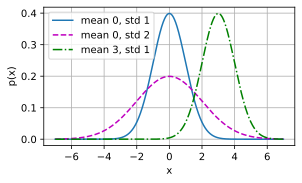

In [46]:
x = np.arange(-7, 7, 0.01)
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
         ylabel='p(x)', figsize=(4.5, 2.5),
         legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

3.2

In [47]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [48]:
def synthetic_data(w,b,num_examples): #@save
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X,w) + b
    y += torch.normal(0,0.01,y.shape)
    return X,y.reshape((-1,1))

true_w = torch.tensor([2,-3.4])
true_b = 4.2
features,labels = synthetic_data(true_w,true_b,1000)

In [49]:
print('features:', features[0],'\nlabel:',labels[0])

features: tensor([-1.5481, -1.4796]) 
label: tensor([6.1178])


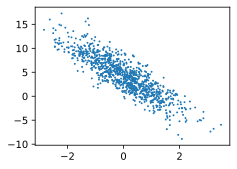

In [50]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(),1)

In [51]:
def data_iter(bath_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    
    random.shuffle(indices)
    for i in range(0,num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [52]:
batch_size = 10

for X,y in data_iter(batch_size,features, labels):
    print(X,'\n',y)
    break
    

tensor([[-0.5077,  1.1188],
        [ 2.4245,  0.0372],
        [-0.6077,  0.1001],
        [ 0.9824,  2.1764],
        [ 0.4842, -1.7491],
        [-0.3877, -0.7356],
        [-0.0210,  0.4271],
        [ 2.6140,  0.8551],
        [-0.7250,  0.3676],
        [ 0.2264,  0.0426]]) 
 tensor([[-0.6212],
        [ 8.9292],
        [ 2.6385],
        [-1.2422],
        [11.1040],
        [ 5.9263],
        [ 2.7269],
        [ 6.5170],
        [ 1.4926],
        [ 4.5026]])


In [53]:
w = torch.normal(0,0.01,size=(2,1),requires_grad=True)
b = torch.zeros(1,requires_grad=True)

In [54]:
def linreg(X,w,b): #@save
    return torch.matmul(X,w)+b

In [55]:
def squared_loss(y_hat,y): #@save
    return(y_hat - y.reshape(y_hat.shape)) ** 2/ 2

In [56]:
def sgd(params,lr,batch_size): #@save
     with torch.no_gard():
            for param in params:
                param -= lr * param.grad / batch_size
                param.grad.zero_()

In [57]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
    def sgd(params, lr, batch_size):
        with torch.no_grad():
            for param in params:
                param -= lr * param.grad / batch_size
                param.grad.zero_()
                print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

In [58]:
3.3
#生成数据集
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features,labels = d2l.synthetic_data(true_w, true_b,1000)

In [61]:
def load_array(data_arrays, batch_size, is_train=True): #@save
    #load_array:用于将特征和标签数组封装成 PyTorch 的 DataLoader
    dataset = data.TensorDataset(*data_arrays)#用 * 解包参数，将它们包装成一个 PyTorch 的 TensorDataset 对象
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10 #设定批量大小为10
data_iter = load_array((features, labels), batch_size)

In [62]:
next(iter(data_iter))

[tensor([[ 0.2636, -1.8472],
         [-1.4211, -0.4091],
         [ 1.6228,  0.0329],
         [ 1.3184,  1.3924],
         [ 2.0623,  2.0759],
         [ 0.7612,  0.9159],
         [-1.8110, -0.2231],
         [ 0.5348, -0.4876],
         [ 0.8072, -0.2901],
         [ 0.4624,  1.3466]]),
 tensor([[10.9968],
         [ 2.7712],
         [ 7.3262],
         [ 2.0886],
         [ 1.2758],
         [ 2.6111],
         [ 1.3383],
         [ 6.9066],
         [ 6.7952],
         [ 0.5323]])]

In [64]:
from torch import nn
net = nn.Sequential(nn.Linear(2,1))

In [65]:
net[0].weight.data.normal_(0,0.01) #指定每个权重参数应该从均值为0、标准差为0.01的正态分布中随机采样
net[0].bias.data.fill_(0)

tensor([0.])

In [66]:
loss = nn.MSELoss()

In [67]:
trainer = torch.optim.SGD(net.parameters(),lr=0.03)

In [68]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch{epoch + 1}, loss{1:f}')
    #每次抓一把数据 -> 让模型猜 -> 算猜错了多少 -> 反思（反向传播） -> 调整大脑（更新参数） -> 扔掉这把，抓下一把 -> 直到把整个数据集抓完（一个 epoch 结束） -> 记录一下总体表现 -> 开始下一个 epoch。

epoch1, loss1.000000
epoch2, loss1.000000
epoch3, loss1.000000


In [70]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：',true_b - b)

w的估计误差： tensor([ 5.3489e-04, -7.3910e-05])
b的估计误差： tensor([0.0008])


3.4